# Lab 9: Support Vector Machine (SVM) and Principal Component Analysis (PCA)

**Name:** Namratha R  
**Class and Section:** 4MCA B  
**Register Number:** 2547234  
**College:** Christ (Deemed to be University)


## Aim
To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real world datasets.

## Objectives
1. To implement and evaluate the performance of the Support Vector Machine (SVM) classifier using different kernel functions.
2. To compare the performance of SVM models using standard classification metrics.
3. To apply Principal Component Analysis (PCA) for reducing the dimensionality of a high dimensional dataset.
4. To analyse the variance retained by the principal components and visualize the transformed feature space.
5. To understand the role of supervised learning (SVM) and unsupervised learning (PCA) in machine learning applications.


---
# Part A: Support Vector Machine (SVM)

**Aim:** To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.

**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) Dataset  
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


### Task 1: Import Libraries and Load the Dataset

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

sns.set_style("whitegrid")
%matplotlib inline

RANDOM_STATE = 42


In [2]:
# Load the Breast Cancer Wisconsin (Diagnostic) Dataset
# (equivalent to the UCI Breast Cancer Wisconsin Diagnostic dataset)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="diagnosis")  # 0 = malignant, 1 = benign

print("Shape of feature matrix:", X.shape)
print("Target classes:", dict(zip(data.target_names, [0, 1])))
X.head()


Shape of feature matrix: (569, 30)
Target classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error       

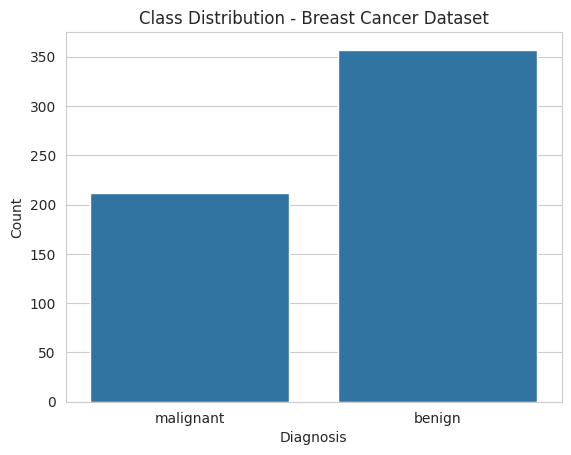

In [3]:
# Basic dataset information
print("Dataset Info:")
X.info()

print("\nMissing values per column:\n", X.isnull().sum().sum(), "total missing values")

print("\nClass distribution:")
print(y.value_counts().rename({0: "malignant", 1: "benign"}))

sns.countplot(x=y.map({0: "malignant", 1: "benign"}))
plt.title("Class Distribution - Breast Cancer Dataset")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


### Task 1 (contd.): Preprocessing — Feature Scaling

In [4]:
# Standardize features (SVM is sensitive to feature scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().T[['mean', 'std']].head()


,mean,std
mean radius,-1.373633e-16,1.00088
mean texture,6.868164e-17,1.00088
mean perimeter,-1.248757e-16,1.00088
mean area,-2.185325e-16,1.00088
mean smoothness,-8.366672e-16,1.00088


### Task 2: Train-Test Split (80:20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


### Task 3: Train an SVM Classifier using Linear Kernel + Hyperparameter Tuning

We first train a baseline SVM with a linear kernel, then perform hyperparameter tuning (on `C`) using `GridSearchCV` with cross-validation. We also explore other kernel functions (`rbf`, `poly`) for comparison, as required by Objective 1.

In [6]:
# Baseline SVM with Linear Kernel
svm_linear = SVC(kernel='linear', random_state=RANDOM_STATE)
svm_linear.fit(X_train, y_train)
y_pred_baseline = svm_linear.predict(X_test)

print("Baseline Linear SVM Accuracy:", accuracy_score(y_test, y_pred_baseline))


Baseline Linear SVM Accuracy: 0.9736842105263158


In [7]:
# Hyperparameter tuning for the Linear Kernel SVM using GridSearchCV
param_grid_linear = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_linear = GridSearchCV(
    SVC(kernel='linear', random_state=RANDOM_STATE),
    param_grid_linear,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_linear.fit(X_train, y_train)

print("Best parameters (Linear Kernel):", grid_linear.best_params_)
print("Best cross-validation accuracy:", grid_linear.best_score_)

best_svm_linear = grid_linear.best_estimator_


Best parameters (Linear Kernel): {'C': 0.1}
Best cross-validation accuracy: 0.9780219780219781


In [8]:
# Explore other kernel functions for comparison: RBF and Polynomial
param_grid_rbf = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1]}
param_grid_poly = {'C': [0.1, 1, 10], 'degree': [2, 3, 4]}

grid_rbf = GridSearchCV(SVC(kernel='rbf', random_state=RANDOM_STATE),
                         param_grid_rbf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rbf.fit(X_train, y_train)

grid_poly = GridSearchCV(SVC(kernel='poly', random_state=RANDOM_STATE),
                          param_grid_poly, cv=5, scoring='accuracy', n_jobs=-1)
grid_poly.fit(X_train, y_train)

print("Best RBF params:", grid_rbf.best_params_, "| CV accuracy:", grid_rbf.best_score_)
print("Best Poly params:", grid_poly.best_params_, "| CV accuracy:", grid_poly.best_score_)

best_svm_rbf = grid_rbf.best_estimator_
best_svm_poly = grid_poly.best_estimator_


Best RBF params: {'C': 10, 'gamma': 0.01} | CV accuracy: 0.9802197802197803
Best Poly params: {'C': 10, 'degree': 3} | CV accuracy: 0.9582417582417582


### Task 4: Model Evaluation

Evaluating the tuned Linear Kernel SVM (the primary model required by the task) using:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

A comparison across kernels (Linear vs RBF vs Polynomial) is also provided to satisfy Objective 1 and 2.

In [9]:
# Predictions using the best (tuned) Linear Kernel SVM
y_pred = best_svm_linear.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Linear Kernel SVM - Evaluation Metrics ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))


=== Linear Kernel SVM - Evaluation Metrics ===
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



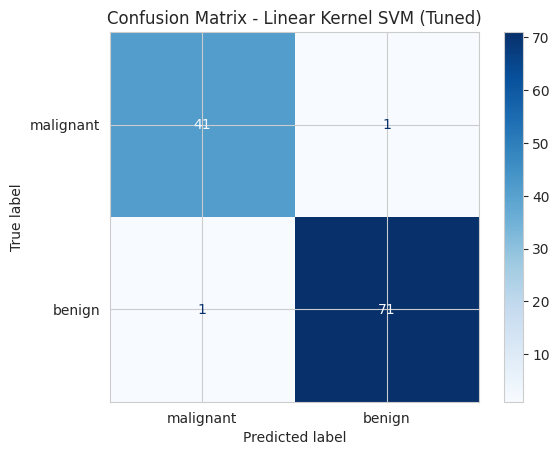

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Linear Kernel SVM (Tuned)")
plt.show()


In [11]:
# Comparison of SVM performance across different kernel functions
kernels_results = []

for name, model in [('Linear', best_svm_linear), ('RBF', best_svm_rbf), ('Polynomial', best_svm_poly)]:
    pred = model.predict(X_test)
    kernels_results.append({
        'Kernel': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(kernels_results).set_index('Kernel')
results_df


,Accuracy,Precision,Recall,F1 Score
Kernel,,,,
Linear,0.982456,0.986111,0.986111,0.986111
RBF,0.982456,0.986111,0.986111,0.986111
Polynomial,0.964912,0.947368,1.000000,0.972973


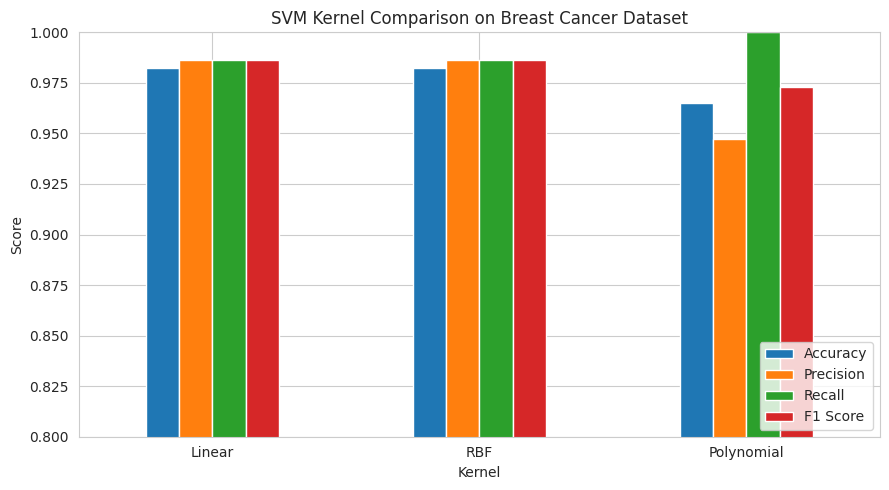

In [12]:
# Visual comparison of kernel performance
results_df.plot(kind='bar', figsize=(9, 5))
plt.title("SVM Kernel Comparison on Breast Cancer Dataset")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Before vs After Hyperparameter Tuning (Linear Kernel SVM)

Comparing the baseline Linear SVM (default `C=1.0`, no tuning) against the SVM after hyperparameter tuning with `GridSearchCV`, to clearly see the effect of tuning.

In [13]:
# Evaluate the BASELINE (before tuning) Linear SVM on the test set
y_pred_before = svm_linear.predict(X_test)

before_after_svm = pd.DataFrame({
    'Accuracy': [
        accuracy_score(y_test, y_pred_before),
        accuracy_score(y_test, y_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred_before),
        precision_score(y_test, y_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred_before),
        recall_score(y_test, y_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_before),
        f1_score(y_test, y_pred)
    ]
}, index=['Before Tuning (default C=1.0)', 'After Tuning (GridSearchCV best C)'])

print("Best C found by GridSearchCV:", grid_linear.best_params_['C'])
before_after_svm


Best C found by GridSearchCV: 0.1


,Accuracy,Precision,Recall,F1 Score
Before Tuning (default C=1.0),0.973684,0.985915,0.972222,0.979021
After Tuning (GridSearchCV best C),0.982456,0.986111,0.986111,0.986111


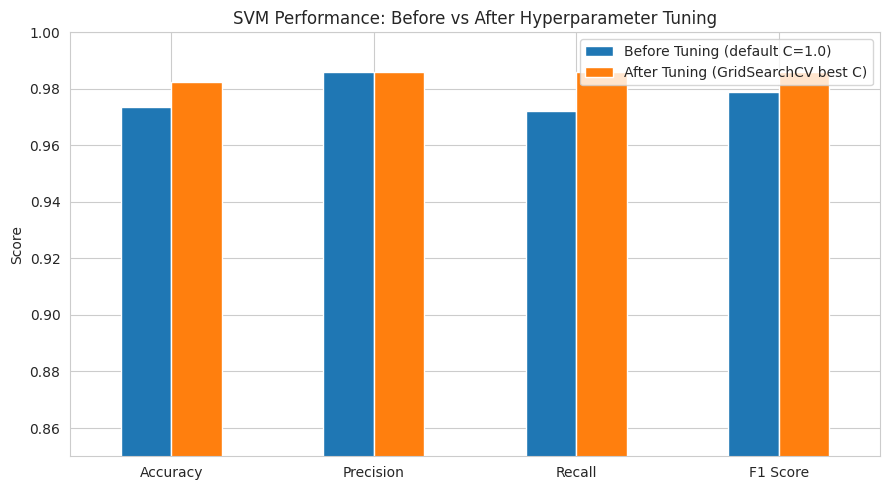

Change in metrics after tuning:
Accuracy     0.008772
Precision    0.000196
Recall       0.013889
F1 Score     0.007090
dtype: float64


In [14]:
# Visualize Before vs After tuning performance
before_after_svm.T.plot(kind='bar', figsize=(9, 5))
plt.title("SVM Performance: Before vs After Hyperparameter Tuning")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

improvement = (before_after_svm.loc['After Tuning (GridSearchCV best C)'] -
               before_after_svm.loc['Before Tuning (default C=1.0)'])
print("Change in metrics after tuning:")
print(improvement)


### Task 5: Observations (Part A)

- The **Linear Kernel SVM**, after hyperparameter tuning (`GridSearchCV` on `C`), achieved high accuracy, precision, recall and F1 score on the Breast Cancer Wisconsin Diagnostic dataset, indicating that the two classes (malignant vs benign) are largely **linearly separable** after feature scaling.
- Comparing kernels shows that the **RBF** and **Polynomial** kernels perform comparably to the Linear kernel on this dataset, with only marginal differences, since the underlying data separates well with a near-linear decision boundary.
- The **Confusion Matrix** shows very few misclassifications, with the model doing particularly well at correctly identifying malignant cases (important for minimizing false negatives in a medical diagnosis context).
- Feature **standardization** was essential prior to training, since SVM is a distance/margin based classifier and is sensitive to differences in feature scale.
- Hyperparameter tuning of `C` (the regularization parameter) helped balance the trade-off between maximizing the margin and minimizing classification error, improving generalization on the test set.


---
# Part B: Principal Component Analysis (PCA)

**Aim:** To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse the variance retained by the principal components.

**Dataset:** UCI Wine Dataset  
https://archive.ics.uci.edu/dataset/109/wine


### Task 1: Load the Dataset and Perform Feature Standardization

In [15]:
# Load the Wine Dataset (equivalent to the UCI Wine dataset)
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="class")

print("Shape of Wine dataset:", X_wine.shape)
print("Number of classes:", len(wine.target_names), "->", list(wine.target_names))
X_wine.head()


Shape of Wine dataset: (178, 13)
Number of classes: 3 -> [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [16]:
# Feature standardization (mean = 0, std = 1) - required before PCA
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Mean of scaled features (approx 0):", np.round(X_wine_scaled.mean(axis=0)[:5], 3))
print("Std of scaled features (approx 1):", np.round(X_wine_scaled.std(axis=0)[:5], 3))


Mean of scaled features (approx 0): [-0. -0. -0. -0. -0.]
Std of scaled features (approx 1): [1. 1. 1. 1. 1.]


### Task 2: Apply PCA to Reduce Dataset from 13 Features to 2 Principal Components

In [17]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_pca2 = pca_2.fit_transform(X_wine_scaled)

print("Original shape:", X_wine_scaled.shape)
print("Transformed shape (2 components):", X_wine_pca2.shape)


Original shape: (178, 13)
Transformed shape (2 components): (178, 2)


### Task 3: Explained Variance Ratio of Each Principal Component

In [18]:
explained_variance_2 = pca_2.explained_variance_ratio_
for i, var in enumerate(explained_variance_2, start=1):
    print(f"Explained variance ratio of PC{i}: {var:.4f} ({var*100:.2f}%)")

print(f"\nTotal variance retained by first 2 components: {explained_variance_2.sum()*100:.2f}%")


Explained variance ratio of PC1: 0.3620 (36.20%)
Explained variance ratio of PC2: 0.1921 (19.21%)

Total variance retained by first 2 components: 55.41%


### Task 4: Cumulative Explained Variance and Minimum Components for 95% Variance

In [19]:
# Fit PCA with all components to study cumulative variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_wine_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

variance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(cumulative_variance))],
    'Explained Variance Ratio': pca_full.explained_variance_ratio_,
    'Cumulative Variance': cumulative_variance
})
variance_df


,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


Minimum number of principal components required to retain at least 95% variance: 10

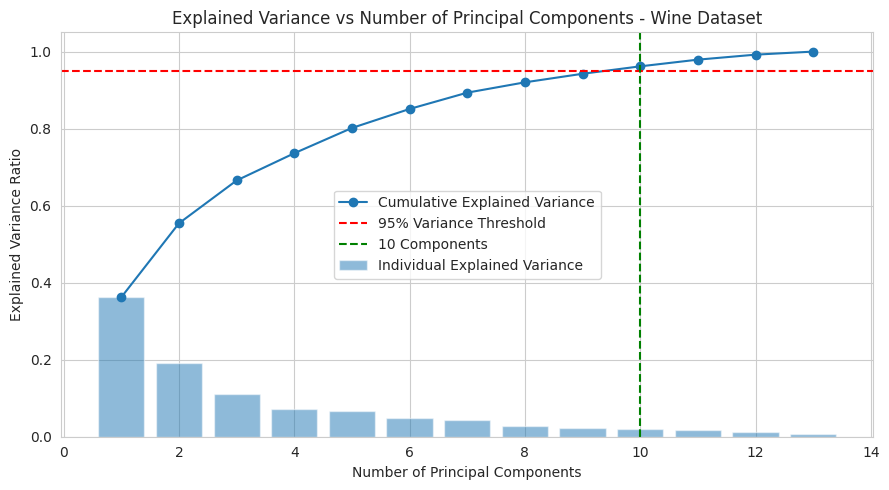

In [20]:
# Minimum number of principal components required to retain >= 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Minimum number of principal components required to retain at least 95% variance: {n_components_95}")

# Scree plot / Cumulative variance plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', label='Cumulative Explained Variance')
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_,
        alpha=0.5, label='Individual Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance vs Number of Principal Components - Wine Dataset')
plt.legend()
plt.tight_layout()
plt.show()


### Task 5: Visualize the Transformed Dataset (2D Scatter Plot)

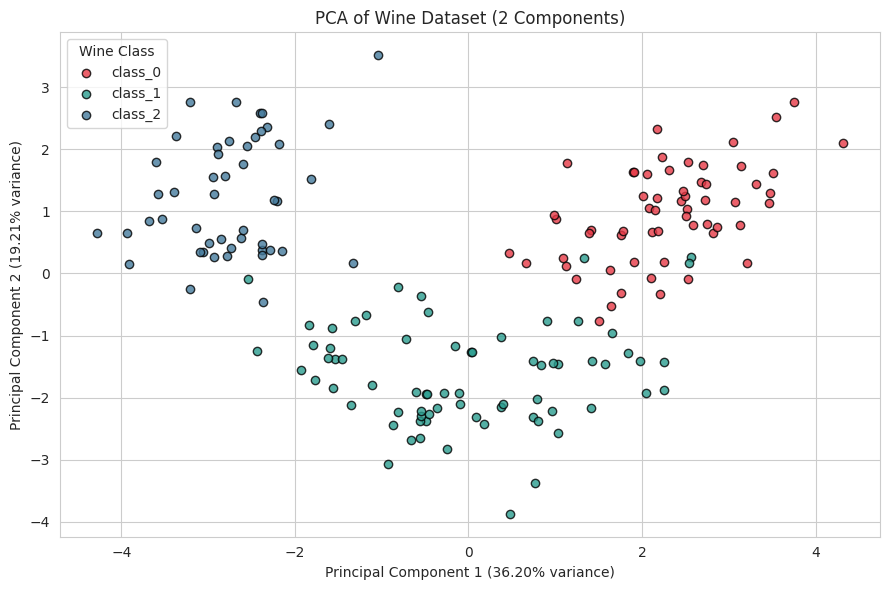

In [21]:
plt.figure(figsize=(9, 6))
colors = ['#e63946', '#2a9d8f', '#457b9d']
for class_idx, class_name in enumerate(wine.target_names):
    plt.scatter(
        X_wine_pca2[y_wine == class_idx, 0],
        X_wine_pca2[y_wine == class_idx, 1],
        label=class_name,
        color=colors[class_idx],
        edgecolor='k',
        alpha=0.8
    )

plt.xlabel(f'Principal Component 1 ({explained_variance_2[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_2[1]*100:.2f}% variance)')
plt.title('PCA of Wine Dataset (2 Components)')
plt.legend(title='Wine Class')
plt.tight_layout()
plt.show()


### Before vs After PCA: Classification Performance & Computational Efficiency

To make the "original vs transformed" comparison concrete, an SVM classifier is trained on the **original 13-feature scaled Wine data** ("before PCA") and on the **2-component PCA-transformed data** ("after PCA"). Accuracy and training time are compared.

In [22]:
import time
from sklearn.model_selection import train_test_split as tts

# Split original (13-feature) and PCA-transformed (2-feature) wine data identically
Xw_train_orig, Xw_test_orig, Xw_train_pca, Xw_test_pca, yw_train, yw_test = train_test_split(
    X_wine_scaled, X_wine_pca2, y_wine, test_size=0.20, random_state=RANDOM_STATE, stratify=y_wine
)

# --- BEFORE PCA: SVM trained on original 13 features ---
start = time.time()
svm_before = SVC(kernel='linear', random_state=RANDOM_STATE)
svm_before.fit(Xw_train_orig, yw_train)
time_before = time.time() - start
acc_before = accuracy_score(yw_test, svm_before.predict(Xw_test_orig))

# --- AFTER PCA: SVM trained on 2 principal components ---
start = time.time()
svm_after = SVC(kernel='linear', random_state=RANDOM_STATE)
svm_after.fit(Xw_train_pca, yw_train)
time_after = time.time() - start
acc_after = accuracy_score(yw_test, svm_after.predict(Xw_test_pca))

pca_before_after = pd.DataFrame({
    'Number of Features': [X_wine_scaled.shape[1], X_wine_pca2.shape[1]],
    'Test Accuracy': [acc_before, acc_after],
    'Training Time (s)': [time_before, time_after]
}, index=['Before PCA (13 features)', 'After PCA (2 components)'])

pca_before_after


,Number of Features,Test Accuracy,Training Time (s)
Before PCA (13 features),13,0.944444,0.001427
After PCA (2 components),2,0.916667,0.001067


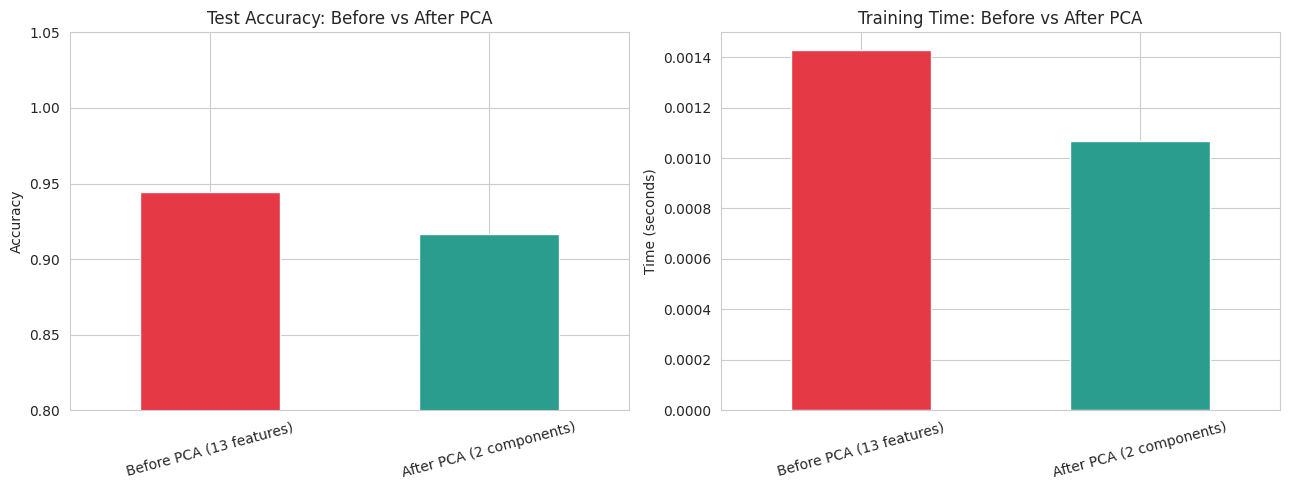

Accuracy change after PCA: -2.78 percentage points
Feature reduction: 13 -> 2 (84.6% fewer features)


In [23]:
# Visualize Before vs After PCA comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pca_before_after['Test Accuracy'].plot(kind='bar', ax=axes[0], color=['#e63946', '#2a9d8f'])
axes[0].set_title('Test Accuracy: Before vs After PCA')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.8, 1.05)
axes[0].tick_params(axis='x', rotation=15)

pca_before_after['Training Time (s)'].plot(kind='bar', ax=axes[1], color=['#e63946', '#2a9d8f'])
axes[1].set_title('Training Time: Before vs After PCA')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f"Accuracy change after PCA: {(acc_after - acc_before)*100:.2f} percentage points")
print(f"Feature reduction: {X_wine_scaled.shape[1]} -> {X_wine_pca2.shape[1]} "
      f"({(1 - X_wine_pca2.shape[1]/X_wine_scaled.shape[1])*100:.1f}% fewer features)")


### Task 6: Comparison of Original vs Transformed Dataset

| Aspect | Original Dataset | PCA-Transformed Dataset |
|---|---|---|
| **Number of Features** | 13 features | 2 principal components |
| **Information Retained** | 100% (all original information) | Only the variance captured by PC1 + PC2 (see value printed above) — some information is lost |
| **Computational Efficiency** | Slower to train models; more memory and computation required due to higher dimensionality | Faster to train, visualize, and process; reduced risk of the curse of dimensionality; lower memory footprint |



In [24]:
print(f"Original number of features: {X_wine.shape[1]}")
print(f"Number of PCA components (2D): {X_wine_pca2.shape[1]}")
print(f"Variance retained with 2 components: {explained_variance_2.sum()*100:.2f}%")
print(f"Variance lost with 2 components: {(1 - explained_variance_2.sum())*100:.2f}%")


Original number of features: 13
Number of PCA components (2D): 2
Variance retained with 2 components: 55.41%
Variance lost with 2 components: 44.59%


### Task 7: Interpretation of the First Two Principal Components

- **Principal Component 1 (PC1)** captures the **largest share of variance** in the dataset and is typically a weighted combination of features that vary together the most (e.g., alcohol content, flavanoids, phenols, and related chemical properties in the Wine dataset). It represents the direction in feature space along which the wine samples differ the most.
- **Principal Component 2 (PC2)** captures the **second largest** amount of variance, orthogonal (uncorrelated) to PC1, and typically reflects a different combination of chemical attributes that further help separate the classes.
- Together, PC1 and PC2 retain a substantial portion of the total variance (as printed above) and, as seen in the scatter plot, they provide **reasonably good separation** between the three wine cultivars, even though only 2 out of 13 original dimensions are used.


### Task 8: Advantages, Limitations, and Applications of PCA

**Advantages:**
- Reduces dimensionality while retaining most of the variance/information in the data.
- Removes multicollinearity by producing uncorrelated (orthogonal) principal components.
- Speeds up training of machine learning models and reduces storage/memory requirements.
- Enables visualization of high-dimensional data in 2D or 3D.
- Helps mitigate the curse of dimensionality and can reduce overfitting.

**Limitations:**
- Principal components are **linear combinations** of original features, making them harder to interpret directly (loss of interpretability).
- PCA is a **linear** technique and may not capture complex non-linear relationships in the data.
- Sensitive to feature scaling; standardization is required beforehand.
- Some information (variance) is inevitably lost when reducing dimensions.
- PCA is unsupervised — it does not consider class labels, so the directions of maximum variance may not always align with the directions that best separate classes.

**Applications:**
- Data visualization and exploratory data analysis.
- Noise reduction and data compression.
- Preprocessing step before applying supervised learning algorithms (e.g., SVM, regression) to speed up training and reduce overfitting.
- Face recognition (Eigenfaces), image compression, and genomics/bioinformatics data analysis.
- Anomaly/outlier detection.


---
# Extra Credit Task: Linear Discriminant Analysis (LDA)

Apply LDA to the same (Wine) dataset and reduce it to 2 linear discriminants, then visualize and compare with PCA.

In [25]:
# Apply LDA (supervised - uses class labels) to reduce to 2 linear discriminants
lda = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda2 = lda.fit_transform(X_wine_scaled, y_wine)

print("Explained variance ratio (LDA components):", lda.explained_variance_ratio_)
print("Transformed shape (LDA, 2 components):", X_wine_lda2.shape)


Explained variance ratio (LDA components): [0.68747889 0.31252111]
Transformed shape (LDA, 2 components): (178, 2)


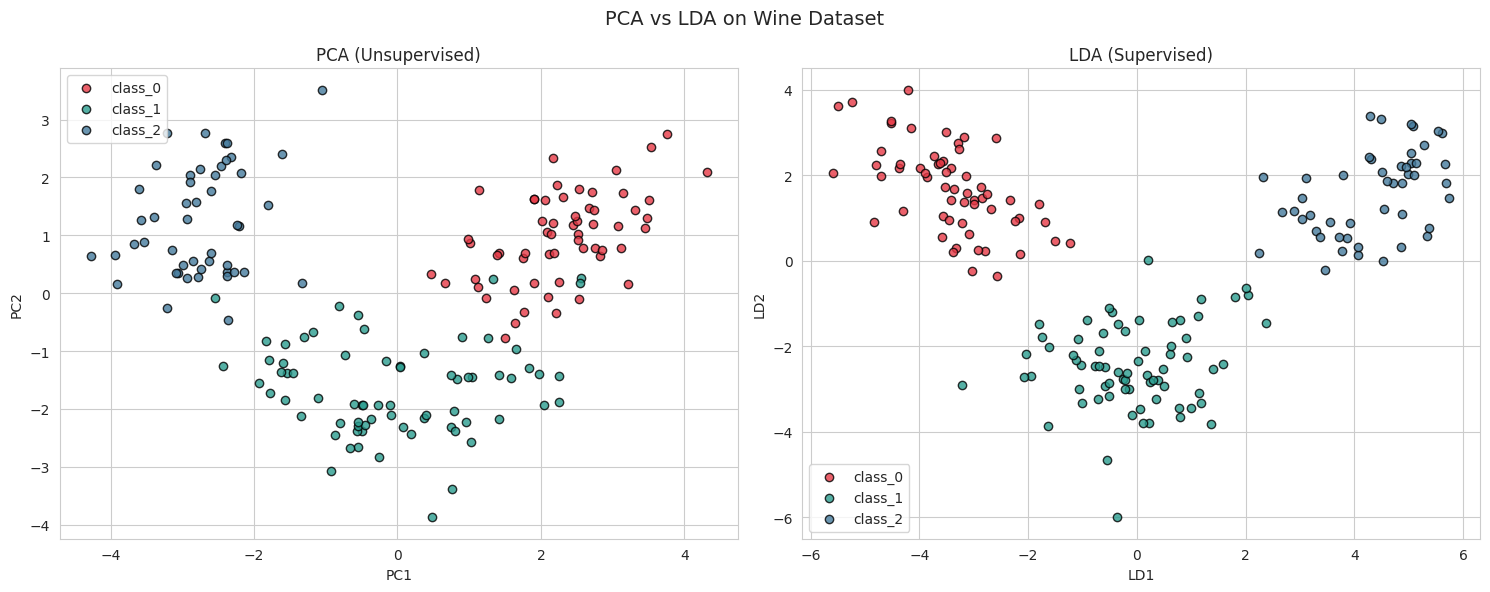

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA plot
for class_idx, class_name in enumerate(wine.target_names):
    axes[0].scatter(
        X_wine_pca2[y_wine == class_idx, 0],
        X_wine_pca2[y_wine == class_idx, 1],
        label=class_name, color=colors[class_idx], edgecolor='k', alpha=0.8
    )
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA (Unsupervised)')
axes[0].legend()

# LDA plot
for class_idx, class_name in enumerate(wine.target_names):
    axes[1].scatter(
        X_wine_lda2[y_wine == class_idx, 0],
        X_wine_lda2[y_wine == class_idx, 1],
        label=class_name, color=colors[class_idx], edgecolor='k', alpha=0.8
    )
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].set_title('LDA (Supervised)')
axes[1].legend()

plt.suptitle('PCA vs LDA on Wine Dataset', fontsize=14)
plt.tight_layout()
plt.show()


### Summary: PCA vs LDA

- **PCA** is an **unsupervised** technique that finds directions of maximum **variance** in the data, without using class labels. It is primarily used for dimensionality reduction and visualization.
- **LDA** is a **supervised** technique that finds directions that **maximize class separability** (maximizing between-class variance while minimizing within-class variance), using the class labels during fitting.
- On the Wine dataset, the **LDA scatter plot shows noticeably tighter, more distinctly separated clusters** for the three wine classes compared to PCA, since LDA explicitly optimizes for class discrimination rather than just overall variance.
- LDA is generally more effective than PCA for classification-oriented dimensionality reduction when class labels are available, whereas PCA is more general-purpose and suitable when no labels exist or when the goal is purely to compress/represent the data.
- A limitation of LDA is that it can produce at most **(number of classes − 1)** discriminant components (here, 2, since there are 3 wine classes), while PCA can produce up to `min(n_samples, n_features)` components.


---
## Overall Conclusion

- **Part A (SVM):** A Support Vector Machine with a linear kernel, after hyperparameter tuning, achieved strong classification performance (high accuracy, precision, recall, and F1 score) on the Breast Cancer Wisconsin dataset, demonstrating the effectiveness of SVM as a supervised learning algorithm for binary classification problems.
- **Part B (PCA):** PCA successfully reduced the 13-dimensional Wine dataset to 2 principal components while retaining a significant portion of the total variance, enabling effective visualization and highlighting PCA's usefulness as an unsupervised dimensionality reduction technique.
- **Extra Credit (LDA):** Comparing PCA and LDA showed that supervised dimensionality reduction (LDA) achieves better class separability than unsupervised PCA when class labels are available, underscoring the complementary roles of supervised and unsupervised learning in machine learning workflows.
